In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\CreditCard-Fraud-Detection\data\fraud_detection_elite_v3.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
df.head(5)


Dataset loaded successfully!
Dataset shape: (12000, 21)


,transaction_id,user_id,amount,transaction_type,merchant_category,timestamp,transaction_frequency,avg_user_amount,deviation_from_avg,transaction_gap_seconds,...,failed_attempts,device_type,location,is_foreign_transaction,unusual_amount_flag,velocity_flag,new_device_flag,location_change_flag,night_transaction_flag,is_fraud
0,T7175,U697,2223.52,transfer,electronics,2026-05-03 16:47:17.308484,8,2071.728078,151.79,2813,...,1,mobile,India,0,0,0,0,0,0,0
1,T10950,U515,1507.74,transfer,fashion,2026-05-03 16:41:02.308484,2,1603.892701,96.15,4460,...,1,mobile,UK,1,0,0,1,0,0,0
2,T3748,U978,2172.87,withdrawal,travel,2026-05-03 13:06:51.308484,10,2815.926122,643.06,2045,...,1,mobile,UK,1,0,1,0,1,0,1
3,T11845,U902,4795.42,transfer,gaming,2026-05-03 17:30:21.308484,3,2507.295598,2288.12,4326,...,2,web,Germany,1,0,0,0,0,0,0
4,T2061,U584,519.97,transfer,electronics,2026-05-03 12:33:07.308484,2,1865.386478,1345.42,4222,...,1,web,UAE,1,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           12000 non-null  str    
 1   user_id                  12000 non-null  str    
 2   amount                   12000 non-null  float64
 3   transaction_type         12000 non-null  str    
 4   merchant_category        12000 non-null  str    
 5   timestamp                12000 non-null  str    
 6   transaction_frequency    12000 non-null  int64  
 7   avg_user_amount          12000 non-null  float64
 8   deviation_from_avg       12000 non-null  float64
 9   transaction_gap_seconds  12000 non-null  int64  
 10  account_age_days         12000 non-null  int64  
 11  failed_attempts          12000 non-null  int64  
 12  device_type              12000 non-null  str    
 13  location                 12000 non-null  str    
 14  is_foreign_transaction   12000 no

In [4]:
df.isnull().sum()

transaction_id             0
user_id                    0
amount                     0
transaction_type           0
merchant_category          0
timestamp                  0
transaction_frequency      0
avg_user_amount            0
deviation_from_avg         0
transaction_gap_seconds    0
account_age_days           0
failed_attempts            0
device_type                0
location                   0
is_foreign_transaction     0
unusual_amount_flag        0
velocity_flag              0
new_device_flag            0
location_change_flag       0
night_transaction_flag     0
is_fraud                   0
dtype: int64

In [5]:
df["is_fraud"].value_counts()

is_fraud
0    11536
1      464
Name: count, dtype: int64

In [6]:
df["is_fraud"].value_counts(normalize=True)*100

is_fraud
0    96.133333
1     3.866667
Name: proportion, dtype: float64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount,12000.0,1780.071891,1180.807318,50.000000,878.010000,1547.080000,2478.23000,7164.120000
transaction_frequency,12000.0,5.844000,3.137380,1.000000,3.000000,6.000000,8.00000,11.000000
avg_user_amount,12000.0,1759.194379,714.160067,500.013842,1149.762448,1780.992279,2365.87353,2999.727655
deviation_from_avg,12000.0,695.817693,614.266176,0.100000,234.187500,525.245000,977.02000,4513.510000
transaction_gap_seconds,12000.0,2803.918833,1822.169056,30.000000,1392.000000,2668.500000,3979.00000,9982.000000
account_age_days,12000.0,996.186500,574.545777,1.000000,513.000000,994.000000,1491.00000,1999.000000
failed_attempts,12000.0,0.968417,0.959425,0.000000,0.000000,1.000000,2.00000,7.000000
is_foreign_transaction,12000.0,0.792167,0.405774,0.000000,1.000000,1.000000,1.00000,1.000000
unusual_amount_flag,12000.0,0.022583,0.148577,0.000000,0.000000,0.000000,0.00000,1.000000
velocity_flag,12000.0,0.248417,0.432113,0.000000,0.000000,0.000000,0.00000,1.000000


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 4806


In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['amount', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'is_fraud']

Categorical columns:
['transaction_id', 'user_id', 'transaction_type', 'merchant_category', 'timestamp', 'device_type', 'location']


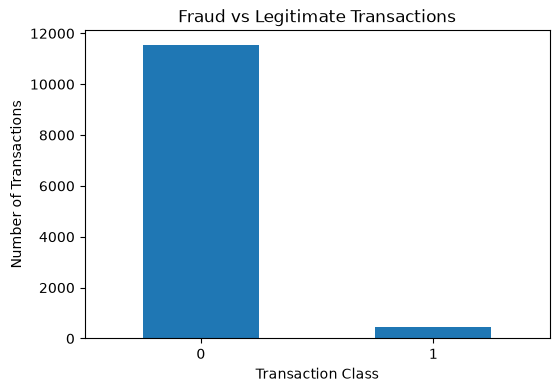

In [10]:
import matplotlib.pyplot as plt

fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(6, 4))
fraud_counts.plot(kind="bar")
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [11]:
fraud_percentage = df["is_fraud"].value_counts(normalize=True) * 100

print(fraud_percentage)

is_fraud
0    96.133333
1     3.866667
Name: proportion, dtype: float64


In [12]:
df.groupby("is_fraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,11536,1780.588649,1550.300,50.0,7164.12
1,464,1767.224203,1440.055,50.0,6587.81


In [13]:
df.groupby("is_fraud")[
    ["amount",
     "transaction_frequency",
     "avg_user_amount",
     "deviation_from_avg",
     "transaction_gap_seconds",
     "failed_attempts"]
].mean()

,amount,transaction_frequency,avg_user_amount,deviation_from_avg,transaction_gap_seconds,failed_attempts
is_fraud,,,,,,
0,1780.588649,5.804092,1759.950213,692.570608,2806.644851,0.964112
1,1767.224203,6.836207,1740.402784,776.546961,2736.144397,1.075431


In [14]:
df.groupby("is_fraud")[
    [
        "unusual_amount_flag",
        "velocity_flag",
        "new_device_flag",
        "location_change_flag",
        "night_transaction_flag"
    ]
].mean()

,unusual_amount_flag,velocity_flag,new_device_flag,location_change_flag,night_transaction_flag
is_fraud,,,,,
0,0.021931,0.240898,0.235870,0.135836,0.002687
1,0.038793,0.435345,0.340517,0.213362,0.000000


In [15]:
print("Total rows:", len(df))
print("Unique transaction IDs:", df["transaction_id"].nunique())
print("Unique user IDs:", df["user_id"].nunique())

Total rows: 12000
Unique transaction IDs: 7194
Unique user IDs: 1198


In [16]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values("transaction_id")

duplicate_rows[
    [
        "transaction_id",
        "user_id",
        "amount",
        "timestamp",
        "is_fraud"
    ]
].head(20)

,transaction_id,user_id,amount,timestamp,is_fraud
184,T0,U228,3558.38,2026-05-03 10:29:17.308484,0
5386,T0,U228,3558.38,2026-05-03 10:29:17.308484,0
9783,T0,U228,3558.38,2026-05-03 10:29:17.308484,0
5495,T1000,U273,1473.04,2026-05-03 12:53:51.308484,1
11397,T1000,U273,1473.04,2026-05-03 12:53:51.308484,1
73,T10000,U832,2830.44,2026-05-03 18:14:15.308484,0
2504,T10000,U832,2830.44,2026-05-03 18:14:15.308484,0
2783,T10000,U832,2830.44,2026-05-03 18:14:15.308484,0
6968,T10005,U58,2158.38,2026-05-03 19:51:10.308484,0
7507,T10005,U58,2158.38,2026-05-03 19:51:10.308484,0


In [17]:
duplicate_id_labels = (
    df.groupby("transaction_id")["is_fraud"]
    .nunique()
)

print("Transaction IDs with conflicting fraud labels:",
      (duplicate_id_labels > 1).sum())

Transaction IDs with conflicting fraud labels: 0


In [18]:
repeated_ids = df["transaction_id"].duplicated(keep=False)

print("Rows with repeated transaction IDs:", repeated_ids.sum())
print("Unique repeated transaction IDs:",
      df.loc[repeated_ids, "transaction_id"].nunique())

Rows with repeated transaction IDs: 8043
Unique repeated transaction IDs: 3237


In [19]:
repeated_ids_list = (
    df["transaction_id"]
    .value_counts()
)

repeated_ids_list[repeated_ids_list > 1].head(10)

transaction_id
T5264     8
T492      7
T10669    7
T5584     6
T6354     6
T5541     6
T9866     6
T5181     6
T823      6
T172      6
Name: count, dtype: int64

In [20]:
example_id = repeated_ids_list[repeated_ids_list > 1].index[0]

df[df["transaction_id"] == example_id].T

,1066,1976,3817,4932,5008,5396,10623,10798
transaction_id,T5264,T5264,T5264,T5264,T5264,T5264,T5264,T5264
user_id,U419,U419,U419,U419,U419,U419,U419,U419
amount,784.34,784.34,784.34,784.34,784.34,784.34,784.34,784.34
transaction_type,transfer,transfer,transfer,transfer,transfer,transfer,transfer,transfer
merchant_category,fashion,fashion,fashion,fashion,fashion,fashion,fashion,fashion
timestamp,2026-05-03 12:34:54.308484,2026-05-03 12:34:54.308484,2026-05-03 12:34:54.308484,2026-05-03 12:34:54.308484,2026-05-03 12:34:54.308484,2026-05-03 12:34:54.308484,2026-05-03 12:34:54.308484,2026-05-03 12:34:54.308484
transaction_frequency,6,6,6,6,6,6,6,6
avg_user_amount,561.53734,561.53734,561.53734,561.53734,561.53734,561.53734,561.53734,561.53734
deviation_from_avg,222.8,222.8,222.8,222.8,222.8,222.8,222.8,222.8
transaction_gap_seconds,385,385,385,385,385,385,385,385


In [21]:
repeated_df = df[df["transaction_id"].duplicated(keep=False)]

repeated_summary = repeated_df.groupby("transaction_id").agg(
    unique_amounts=("amount", "nunique"),
    unique_timestamps=("timestamp", "nunique"),
    unique_users=("user_id", "nunique"),
    unique_labels=("is_fraud", "nunique")
)

repeated_summary.describe()

,unique_amounts,unique_timestamps,unique_users,unique_labels
count,3237.0,3237.0,3237.0,3237.0
mean,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0


In [22]:
df_clean = df.copy()

print("Before removing duplicates:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("After removing duplicates:", df_clean.shape)

print("Rows removed:", len(df) - len(df_clean))

Before removing duplicates: (12000, 21)
After removing duplicates: (7194, 21)
Rows removed: 4806


In [23]:
print(df_clean["is_fraud"].value_counts())

print("\nFraud percentage:")
print(df_clean["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    6762
1     432
Name: count, dtype: int64

Fraud percentage:
is_fraud
0    93.994996
1     6.005004
Name: proportion, dtype: float64


In [24]:
print("Duplicate rows remaining:", df_clean.duplicated().sum())
print("Unique transaction IDs:", df_clean["transaction_id"].nunique())
print("Total rows:", len(df_clean))

Duplicate rows remaining: 0
Unique transaction IDs: 7194
Total rows: 7194


In [25]:
print("Rows:", len(df_clean))
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())
print("Unique transaction IDs:", df_clean["transaction_id"].nunique())
print("Fraud cases:", df_clean["is_fraud"].sum())
print("Legitimate cases:", (df_clean["is_fraud"] == 0).sum())

Rows: 7194
Columns: 21
Duplicate rows: 0
Unique transaction IDs: 7194
Fraud cases: 432
Legitimate cases: 6762


In [26]:
print("Rows:", len(df_clean))
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())
print("Unique transaction IDs:", df_clean["transaction_id"].nunique())
print("Fraud cases:", df_clean["is_fraud"].sum())
print("Legitimate cases:", (df_clean["is_fraud"] == 0).sum())

Rows: 7194
Columns: 21
Duplicate rows: 0
Unique transaction IDs: 7194
Fraud cases: 432
Legitimate cases: 6762


In [27]:
flag_columns = [
    "unusual_amount_flag",
    "velocity_flag",
    "new_device_flag",
    "location_change_flag",
    "night_transaction_flag"
]

df_clean[flag_columns].describe()

,unusual_amount_flag,velocity_flag,new_device_flag,location_change_flag,night_transaction_flag
count,7194.000000,7194.000000,7194.000000,7194.000000,7194.000000
mean,0.021963,0.253128,0.237559,0.140951,0.002502
std,0.146572,0.434834,0.425617,0.347995,0.049962
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
for col in flag_columns:
    print(f"\n--- {col} ---")
    print(pd.crosstab(
        df_clean[col],
        df_clean["is_fraud"],
        normalize="index"
    ) * 100)


--- unusual_amount_flag ---
is_fraud                     0          1
unusual_amount_flag                      
0                    94.115975   5.884025
1                    88.607595  11.392405

--- velocity_flag ---
is_fraud               0          1
velocity_flag                      
0              95.533222   4.466778
1              89.456343  10.543657

--- new_device_flag ---
is_fraud                 0         1
new_device_flag                     
0                94.895169  5.104831
1                91.105910  8.894090

--- location_change_flag ---
is_fraud                      0         1
location_change_flag                     
0                     94.514563  5.485437
1                     90.828402  9.171598

--- night_transaction_flag ---
is_fraud                         0         1
night_transaction_flag                      
0                        93.979933  6.020067
1                       100.000000  0.000000


In [29]:
df_clean["night_transaction_flag"].value_counts()

night_transaction_flag
0    7176
1      18
Name: count, dtype: int64

In [30]:
pd.crosstab(
    df_clean["night_transaction_flag"],
    df_clean["is_fraud"]
)

is_fraud,0,1
night_transaction_flag,,
0,6744,432
1,18,0


In [31]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")

df_clean["hour"] = df_clean["timestamp"].dt.hour

pd.crosstab(
    df_clean["hour"],
    df_clean["night_transaction_flag"]
)

night_transaction_flag,0,1
hour,,
0,0,13
1,0,3
2,0,1
3,0,1
9,39,0
10,401,0
11,740,0
12,1061,0
13,1000,0


In [32]:
print("Missing timestamps:", df_clean["timestamp"].isna().sum())
print("Timestamp data type:", df_clean["timestamp"].dtype)

Missing timestamps: 0
Timestamp data type: datetime64[us]


In [33]:
pd.crosstab(
    df_clean["hour"],
    df_clean["night_transaction_flag"]
)

night_transaction_flag,0,1
hour,,
0,0,13
1,0,3
2,0,1
3,0,1
9,39,0
10,401,0
11,740,0
12,1061,0
13,1000,0


In [34]:
df_clean[df_clean["night_transaction_flag"] == 1][
    ["timestamp", "hour", "amount", "is_fraud"]
]

,timestamp,hour,amount,is_fraud
72,2026-05-04 01:56:53.308484,1,998.25,0
392,2026-05-04 00:02:55.308484,0,1400.78,0
787,2026-05-04 00:33:39.308484,0,2276.53,0
1511,2026-05-04 00:03:39.308484,0,3420.47,0
2649,2026-05-04 00:08:15.308484,0,798.01,0
3208,2026-05-04 01:08:03.308484,1,865.34,0
3268,2026-05-04 00:53:34.308484,0,1281.68,0
4578,2026-05-04 00:43:03.308484,0,628.87,0
4701,2026-05-04 00:50:50.308484,0,778.31,0
5355,2026-05-04 00:02:58.308484,0,1407.63,0


In [35]:
# Step 1: Analyze duplicate rows

duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))

print("\nSample duplicate records:")
display(duplicate_rows.head(10))

Total duplicate rows: 8043

Sample duplicate records:


,transaction_id,user_id,amount,transaction_type,merchant_category,timestamp,transaction_frequency,avg_user_amount,deviation_from_avg,transaction_gap_seconds,...,failed_attempts,device_type,location,is_foreign_transaction,unusual_amount_flag,velocity_flag,new_device_flag,location_change_flag,night_transaction_flag,is_fraud
0,T7175,U697,2223.52,transfer,electronics,2026-05-03 16:47:17.308484,8,2071.728078,151.79,2813,...,1,mobile,India,0,0,0,0,0,0,0
3,T11845,U902,4795.42,transfer,gaming,2026-05-03 17:30:21.308484,3,2507.295598,2288.12,4326,...,2,web,Germany,1,0,0,0,0,0,0
4,T2061,U584,519.97,transfer,electronics,2026-05-03 12:33:07.308484,2,1865.386478,1345.42,4222,...,1,web,UAE,1,0,0,0,0,0,0
5,T5042,U499,1298.73,payment,gaming,2026-05-03 14:48:09.308484,11,2124.371747,825.64,3497,...,2,mobile,UAE,1,0,1,1,1,0,0
6,T8082,U1194,6092.12,payment,electronics,2026-05-03 13:12:25.308484,11,2993.845915,3098.27,671,...,1,web,UAE,1,1,1,1,1,0,0
8,T4368,U58,642.88,withdrawal,grocery,2026-05-03 17:33:46.308484,11,540.416274,102.46,4975,...,1,mobile,Germany,1,0,1,1,0,0,0
9,T7214,U863,571.16,transfer,gaming,2026-05-03 15:32:46.308484,4,868.223417,297.06,1820,...,1,mobile,UAE,1,0,0,0,0,0,0
10,T2976,U734,50.00,withdrawal,electronics,2026-05-03 12:23:05.308484,1,2106.432981,2056.43,8941,...,1,mobile,India,0,0,0,1,0,0,0
11,T8795,U955,4012.06,withdrawal,fashion,2026-05-03 17:31:55.308484,10,2587.816813,1424.24,611,...,1,web,India,0,0,1,0,0,0,0
14,T9667,U540,1690.01,transfer,grocery,2026-05-03 18:24:23.308484,8,2253.487497,563.48,3028,...,2,web,India,0,0,0,1,1,0,0


In [36]:
# Step 2: Check repeated transaction IDs

transaction_id_counts = df["transaction_id"].value_counts()

repeated_transaction_ids = transaction_id_counts[
    transaction_id_counts > 1
]

print("Number of repeated transaction IDs:",
      len(repeated_transaction_ids))

print("\nMost repeated transaction IDs:")
display(repeated_transaction_ids.head(10))

Number of repeated transaction IDs: 3237

Most repeated transaction IDs:


transaction_id
T5264     8
T492      7
T10669    7
T5584     6
T6354     6
T5541     6
T9866     6
T5181     6
T823      6
T172      6
Name: count, dtype: int64

In [37]:
# Step 3: Inspect repeated transactions

repeated_ids = repeated_transaction_ids.index

repeated_transactions = df[
    df["transaction_id"].isin(repeated_ids)
]

display(repeated_transactions.head(20))

,transaction_id,user_id,amount,transaction_type,merchant_category,timestamp,transaction_frequency,avg_user_amount,deviation_from_avg,transaction_gap_seconds,...,failed_attempts,device_type,location,is_foreign_transaction,unusual_amount_flag,velocity_flag,new_device_flag,location_change_flag,night_transaction_flag,is_fraud
0,T7175,U697,2223.52,transfer,electronics,2026-05-03 16:47:17.308484,8,2071.728078,151.79,2813,...,1,mobile,India,0,0,0,0,0,0,0
3,T11845,U902,4795.42,transfer,gaming,2026-05-03 17:30:21.308484,3,2507.295598,2288.12,4326,...,2,web,Germany,1,0,0,0,0,0,0
4,T2061,U584,519.97,transfer,electronics,2026-05-03 12:33:07.308484,2,1865.386478,1345.42,4222,...,1,web,UAE,1,0,0,0,0,0,0
5,T5042,U499,1298.73,payment,gaming,2026-05-03 14:48:09.308484,11,2124.371747,825.64,3497,...,2,mobile,UAE,1,0,1,1,1,0,0
6,T8082,U1194,6092.12,payment,electronics,2026-05-03 13:12:25.308484,11,2993.845915,3098.27,671,...,1,web,UAE,1,1,1,1,1,0,0
8,T4368,U58,642.88,withdrawal,grocery,2026-05-03 17:33:46.308484,11,540.416274,102.46,4975,...,1,mobile,Germany,1,0,1,1,0,0,0
9,T7214,U863,571.16,transfer,gaming,2026-05-03 15:32:46.308484,4,868.223417,297.06,1820,...,1,mobile,UAE,1,0,0,0,0,0,0
10,T2976,U734,50.00,withdrawal,electronics,2026-05-03 12:23:05.308484,1,2106.432981,2056.43,8941,...,1,mobile,India,0,0,0,1,0,0,0
11,T8795,U955,4012.06,withdrawal,fashion,2026-05-03 17:31:55.308484,10,2587.816813,1424.24,611,...,1,web,India,0,0,1,0,0,0,0
14,T9667,U540,1690.01,transfer,grocery,2026-05-03 18:24:23.308484,8,2253.487497,563.48,3028,...,2,web,India,0,0,0,1,1,0,0


In [38]:
# Step 4: Check fraud labels for repeated transaction IDs

fraud_label_check = (
    repeated_transactions
    .groupby("transaction_id")["is_fraud"]
    .nunique()
)

conflicting_transactions = fraud_label_check[
    fraud_label_check > 1
]

print("Transaction IDs with conflicting fraud labels:",
      len(conflicting_transactions))

print("\nConflicting transaction IDs:")
display(conflicting_transactions)

Transaction IDs with conflicting fraud labels: 0

Conflicting transaction IDs:


Series([], Name: is_fraud, dtype: int64)

In [39]:
# Inspect conflicting transactions

conflicting_ids = conflicting_transactions.index

conflicting_records = repeated_transactions[
    repeated_transactions["transaction_id"].isin(conflicting_ids)
]

display(conflicting_records)

,transaction_id,user_id,amount,transaction_type,merchant_category,timestamp,transaction_frequency,avg_user_amount,deviation_from_avg,transaction_gap_seconds,...,failed_attempts,device_type,location,is_foreign_transaction,unusual_amount_flag,velocity_flag,new_device_flag,location_change_flag,night_transaction_flag,is_fraud


In [40]:
print("Before removing duplicates:", df.shape)

print("Duplicate rows:", df.duplicated().sum())

Before removing duplicates: (12000, 21)
Duplicate rows: 4806


In [41]:
# Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

print("After removing duplicates:", df_clean.shape)

After removing duplicates: (7194, 21)


In [42]:
print("Remaining duplicate rows:",
      df_clean.duplicated().sum())

Remaining duplicate rows: 0


In [43]:
print("Fraud distribution after cleaning:")

print(df_clean["is_fraud"].value_counts())

print("\nFraud percentage:")
print(df_clean["is_fraud"].value_counts(normalize=True) * 100)

Fraud distribution after cleaning:
is_fraud
0    6762
1     432
Name: count, dtype: int64

Fraud percentage:
is_fraud
0    93.994996
1     6.005004
Name: proportion, dtype: float64


In [44]:
# Step 8: Check unique values in categorical columns

categorical_columns = df_clean.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Unique values:", df_clean[col].nunique())
    print(df_clean[col].unique()[:20])

Categorical columns:
['transaction_id', 'user_id', 'transaction_type', 'merchant_category', 'timestamp', 'device_type', 'location']

--- transaction_id ---
Unique values: 7194
<ArrowStringArray>
[ 'T7175', 'T10950',  'T3748', 'T11845',  'T2061',  'T5042',  'T8082',
  'T7244',  'T4368',  'T7214',  'T2976',  'T8795', 'T10708',  'T4322',
  'T9667', 'T11981',  'T9445',  'T8083',  'T4560',  'T7133']
Length: 20, dtype: str

--- user_id ---
Unique values: 1198
<ArrowStringArray>
[ 'U697',  'U515',  'U978',  'U902',  'U584',  'U499', 'U1194',  'U770',
   'U58',  'U863',  'U734',  'U955',  'U711',  'U222',  'U540',   'U75',
 'U1083',  'U764',  'U858',  'U223']
Length: 20, dtype: str

--- transaction_type ---
Unique values: 3
<ArrowStringArray>
['transfer', 'withdrawal', 'payment']
Length: 3, dtype: str

--- merchant_category ---
Unique values: 5
<ArrowStringArray>
['electronics', 'fashion', 'travel', 'gaming', 'grocery']
Length: 5, dtype: str

--- timestamp ---
Unique values: 6497
<ArrowStringA

C:\Users\ramya\AppData\Local\Temp\ipykernel_6336\3735206711.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(


In [45]:
# Step 9: Check for leading/trailing spaces

for col in categorical_columns:
    if df_clean[col].dtype == "object" or "string" in str(df_clean[col].dtype):
        spaces = df_clean[col].astype(str).str.strip() != df_clean[col].astype(str)
        print(f"{col}: {spaces.sum()} values with extra spaces")


In [46]:
# Step 10: Check missing values again after cleaning

missing_values = df_clean.isnull().sum()

print("Columns with missing values:")
display(missing_values[missing_values > 0])

Columns with missing values:


Series([], dtype: int64)

In [47]:
# Step 11: Convert timestamp to datetime

df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

print(df_clean["timestamp"].dtype)
print(df_clean["timestamp"].head())

datetime64[us]
0   2026-05-03 16:47:17.308484
1   2026-05-03 16:41:02.308484
2   2026-05-03 13:06:51.308484
3   2026-05-03 17:30:21.308484
4   2026-05-03 12:33:07.308484
Name: timestamp, dtype: datetime64[us]


In [48]:
# Step 12: Create time-based features

df_clean["hour"] = df_clean["timestamp"].dt.hour
df_clean["day_of_week"] = df_clean["timestamp"].dt.dayofweek
df_clean["month"] = df_clean["timestamp"].dt.month
df_clean["is_weekend"] = (
    df_clean["day_of_week"] >= 5
).astype(int)

print("Time-based features created successfully.")

display(
    df_clean[
        ["timestamp", "hour", "day_of_week", "month", "is_weekend"]
    ].head(10)
)

Time-based features created successfully.


,timestamp,hour,day_of_week,month,is_weekend
0,2026-05-03 16:47:17.308484,16,6,5,1
1,2026-05-03 16:41:02.308484,16,6,5,1
2,2026-05-03 13:06:51.308484,13,6,5,1
3,2026-05-03 17:30:21.308484,17,6,5,1
4,2026-05-03 12:33:07.308484,12,6,5,1
5,2026-05-03 14:48:09.308484,14,6,5,1
6,2026-05-03 13:12:25.308484,13,6,5,1
7,2026-05-03 11:16:36.308484,11,6,5,1
8,2026-05-03 17:33:46.308484,17,6,5,1
9,2026-05-03 15:32:46.308484,15,6,5,1


In [49]:
# Step 13: Check time-based feature distributions

print("Hour distribution:")
display(df_clean["hour"].value_counts().sort_index())

print("\nDay of week distribution:")
display(df_clean["day_of_week"].value_counts().sort_index())

print("\nMonth distribution:")
display(df_clean["month"].value_counts().sort_index())

print("\nWeekend distribution:")
display(df_clean["is_weekend"].value_counts())

Hour distribution:


hour
0       13
1        3
2        1
3        1
9       39
10     401
11     740
12    1061
13    1000
14     927
15     773
16     701
17     554
18     360
19     276
20     177
21      83
22      67
23      17
Name: count, dtype: int64


Day of week distribution:


day_of_week
0      18
6    7176
Name: count, dtype: int64


Month distribution:


month
5    7194
Name: count, dtype: int64


Weekend distribution:


is_weekend
1    7176
0      18
Name: count, dtype: int64

In [50]:
# Step 14: Fraud distribution by hour

fraud_by_hour = (
    df_clean.groupby("hour")["is_fraud"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

fraud_by_hour.columns = [
    "hour",
    "total_transactions",
    "fraud_count",
    "fraud_rate"
]

fraud_by_hour["fraud_rate"] *= 100

display(fraud_by_hour)

,hour,total_transactions,fraud_count,fraud_rate
0,0,13,0,0.000000
1,1,3,0,0.000000
2,2,1,0,0.000000
3,3,1,0,0.000000
4,9,39,1,2.564103
5,10,401,24,5.985037
6,11,740,33,4.459459
7,12,1061,51,4.806786
8,13,1000,63,6.300000
9,14,927,60,6.472492


In [51]:
# Step 15: Check numerical features available after cleaning

numerical_columns = df_clean.select_dtypes(
    include=["number"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['amount', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'is_fraud', 'hour', 'day_of_week', 'month', 'is_weekend']


In [52]:
# Check the first few rows of the numerical features

display(df_clean[numerical_columns].head())

,amount,transaction_frequency,avg_user_amount,deviation_from_avg,transaction_gap_seconds,account_age_days,failed_attempts,is_foreign_transaction,unusual_amount_flag,velocity_flag,new_device_flag,location_change_flag,night_transaction_flag,is_fraud,hour,day_of_week,month,is_weekend
0,2223.52,8,2071.728078,151.79,2813,794,1,0,0,0,0,0,0,0,16,6,5,1
1,1507.74,2,1603.892701,96.15,4460,1809,1,1,0,0,1,0,0,0,16,6,5,1
2,2172.87,10,2815.926122,643.06,2045,682,1,1,0,1,0,1,0,1,13,6,5,1
3,4795.42,3,2507.295598,2288.12,4326,349,2,1,0,0,0,0,0,0,17,6,5,1
4,519.97,2,1865.386478,1345.42,4222,583,1,1,0,0,0,0,0,0,12,6,5,1


In [53]:
# Feature Engineering 1: Night-time transaction

df_clean["is_night"] = (
    (df_clean["hour"] >= 0) & 
    (df_clean["hour"] <= 5)
).astype(int)

print("is_night feature created successfully.")

display(
    df_clean[
        ["hour", "is_night", "is_weekend", "is_fraud"]
    ].head(10)
)

is_night feature created successfully.


,hour,is_night,is_weekend,is_fraud
0,16,0,1,0
1,16,0,1,0
2,13,0,1,1
3,17,0,1,0
4,12,0,1,0
5,14,0,1,0
6,13,0,1,0
7,11,0,1,0
8,17,0,1,0
9,15,0,1,0


In [54]:
# Feature Engineering 2: Log transformation of transaction amount

import numpy as np

df_clean["log_amount"] = np.log1p(df_clean["amount"])

print("log_amount feature created successfully.")

display(
    df_clean[
        ["amount", "log_amount", "is_fraud"]
    ].head(10)
)

log_amount feature created successfully.


,amount,log_amount,is_fraud
0,2223.52,7.707296,0
1,1507.74,7.319030,0
2,2172.87,7.684264,1
3,4795.42,8.475625,0
4,519.97,6.255692,0
5,1298.73,7.169912,0
6,6092.12,8.714916,0
7,793.78,6.678065,0
8,642.88,6.467512,0
9,571.16,6.349419,0


In [55]:
# Verify feature engineering

new_features = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_night",
    "log_amount"
]

display(df_clean[new_features].head(10))

print("\nNew dataset shape:", df_clean.shape)

,hour,day_of_week,month,is_weekend,is_night,log_amount
0,16,6,5,1,0,7.707296
1,16,6,5,1,0,7.319030
2,13,6,5,1,0,7.684264
3,17,6,5,1,0,8.475625
4,12,6,5,1,0,6.255692
5,14,6,5,1,0,7.169912
6,13,6,5,1,0,8.714916
7,11,6,5,1,0,6.678065
8,17,6,5,1,0,6.467512
9,15,6,5,1,0,6.349419



New dataset shape: (7194, 27)


In [56]:
# Step 16: Inspect all current columns

print("Total columns:", len(df_clean.columns))

for i, col in enumerate(df_clean.columns, start=1):
    print(i, "->", col)

Total columns: 27
1 -> transaction_id
2 -> user_id
3 -> amount
4 -> transaction_type
5 -> merchant_category
6 -> timestamp
7 -> transaction_frequency
8 -> avg_user_amount
9 -> deviation_from_avg
10 -> transaction_gap_seconds
11 -> account_age_days
12 -> failed_attempts
13 -> device_type
14 -> location
15 -> is_foreign_transaction
16 -> unusual_amount_flag
17 -> velocity_flag
18 -> new_device_flag
19 -> location_change_flag
20 -> night_transaction_flag
21 -> is_fraud
22 -> hour
23 -> day_of_week
24 -> month
25 -> is_weekend
26 -> is_night
27 -> log_amount


In [57]:
# Step 17: Identify numerical behavioral features

numerical_columns = df_clean.select_dtypes(
    include=["number"]
).columns.tolist()

print("\nNumerical columns:")
print(numerical_columns)


Numerical columns:
['amount', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'is_fraud', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'log_amount']


In [58]:
# Step 18: Amount relative to user's average transaction

df_clean["amount_to_avg_ratio"] = (
    df_clean["amount"] /
    (df_clean["avg_user_amount"] + 1e-6)
)

print("amount_to_avg_ratio created successfully.")

display(
    df_clean[
        ["amount", "avg_user_amount", "amount_to_avg_ratio", "is_fraud"]
    ].head(10)
)

amount_to_avg_ratio created successfully.


,amount,avg_user_amount,amount_to_avg_ratio,is_fraud
0,2223.52,2071.728078,1.073268,0
1,1507.74,1603.892701,0.940050,0
2,2172.87,2815.926122,0.771636,1
3,4795.42,2507.295598,1.912587,0
4,519.97,1865.386478,0.278747,0
5,1298.73,2124.371747,0.611348,0
6,6092.12,2993.845915,2.034881,0
7,793.78,2416.024176,0.328548,0
8,642.88,540.416274,1.189601,0
9,571.16,868.223417,0.657849,0


In [59]:
# Step 19: Log transformation of transaction frequency

df_clean["log_transaction_frequency"] = np.log1p(
    df_clean["transaction_frequency"]
)

print("log_transaction_frequency created successfully.")

display(
    df_clean[
        ["transaction_frequency",
         "log_transaction_frequency",
         "is_fraud"]
    ].head(10)
)

log_transaction_frequency created successfully.


,transaction_frequency,log_transaction_frequency,is_fraud
0,8,2.197225,0
1,2,1.098612,0
2,10,2.397895,1
3,3,1.386294,0
4,2,1.098612,0
5,11,2.484907,0
6,11,2.484907,0
7,6,1.945910,0
8,11,2.484907,0
9,4,1.609438,0


In [60]:
# Step 20: Log transformation of transaction gap

df_clean["log_transaction_gap"] = np.log1p(
    df_clean["transaction_gap_seconds"]
)

print("log_transaction_gap created successfully.")

display(
    df_clean[
        ["transaction_gap_seconds",
         "log_transaction_gap",
         "is_fraud"]
    ].head(10)
)

log_transaction_gap created successfully.


,transaction_gap_seconds,log_transaction_gap,is_fraud
0,2813,7.942362,0
1,4460,8.403128,0
2,2045,7.623642,1
3,4326,8.372630,0
4,4222,8.348301,0
5,3497,8.159947,0
6,671,6.510258,0
7,3751,8.230044,0
8,4975,8.512382,0
9,1820,7.507141,0


In [61]:
# Step 21: Verify engineered features

engineered_features = [
    "amount_to_avg_ratio",
    "log_transaction_frequency",
    "log_transaction_gap"
]

display(df_clean[engineered_features].head(10))

print("Dataset shape:", df_clean.shape)

,amount_to_avg_ratio,log_transaction_frequency,log_transaction_gap
0,1.073268,2.197225,7.942362
1,0.940050,1.098612,8.403128
2,0.771636,2.397895,7.623642
3,1.912587,1.386294,8.372630
4,0.278747,1.098612,8.348301
5,0.611348,2.484907,8.159947
6,2.034881,2.484907,6.510258
7,0.328548,1.945910,8.230044
8,1.189601,2.484907,8.512382
9,0.657849,1.609438,7.507141


Dataset shape: (7194, 30)


In [62]:
# Step 22: Validate engineered features

check_features = [
    "amount_to_avg_ratio",
    "log_transaction_frequency",
    "log_transaction_gap"
]

print("Missing values:")
print(df_clean[check_features].isnull().sum())

print("\nInfinite values:")
print(np.isinf(df_clean[check_features]).sum())

print("\nSummary statistics:")
display(df_clean[check_features].describe().T)

Missing values:
amount_to_avg_ratio          0
log_transaction_frequency    0
log_transaction_gap          0
dtype: int64

Infinite values:
amount_to_avg_ratio          0
log_transaction_frequency    0
log_transaction_gap          0
dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
amount_to_avg_ratio,7194.0,1.009696,0.488843,0.016695,0.661065,1.002263,1.338150,3.073947
log_transaction_frequency,7194.0,1.794954,0.547516,0.693147,1.386294,1.945910,2.302585,2.484907
log_transaction_gap,7194.0,7.633558,0.925859,3.433987,7.232191,7.887959,8.286206,9.208639


In [63]:
# Step 23: Check extreme amount-to-average ratios

print("Top 10 amount-to-average ratios:")

display(
    df_clean[
        ["amount", "avg_user_amount", "amount_to_avg_ratio", "is_fraud"]
    ]
    .sort_values("amount_to_avg_ratio", ascending=False)
    .head(10)
)

Top 10 amount-to-average ratios:


,amount,avg_user_amount,amount_to_avg_ratio,is_fraud
1109,5390.31,1753.546772,3.073947,1
1884,1794.47,608.007161,2.951396,0
2309,7164.12,2650.607836,2.702822,0
11540,4820.25,1791.167691,2.691122,1
8196,6083.41,2275.445082,2.673503,0
11853,1694.03,649.129865,2.609694,0
4909,4989.89,1925.377780,2.591642,0
2023,3478.29,1342.601114,2.590710,1
9472,6683.21,2580.056663,2.590335,0
1794,2234.52,875.574356,2.552062,0


In [64]:
# Check complete dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFraud Distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud Percentage:")
print(df["is_fraud"].value_counts(normalize=True) * 100)

Dataset Shape: (12000, 21)

Column Names:
['transaction_id', 'user_id', 'amount', 'transaction_type', 'merchant_category', 'timestamp', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'device_type', 'location', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'is_fraud']

Data Types:
transaction_id                 str
user_id                        str
amount                     float64
transaction_type               str
merchant_category              str
timestamp                      str
transaction_frequency        int64
avg_user_amount            float64
deviation_from_avg         float64
transaction_gap_seconds      int64
account_age_days             int64
failed_attempts              int64
device_type                    str
location                       str
is_foreign_transaction       int64
unusual_amount_flag 

In [65]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract useful time-based features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Check the new features
print(df[["timestamp", "hour", "day_of_week", "month", "is_weekend"]].head())

                   timestamp  hour  day_of_week  month  is_weekend
0 2026-05-03 16:47:17.308484    16            6      5           1
1 2026-05-03 16:41:02.308484    16            6      5           1
2 2026-05-03 13:06:51.308484    13            6      5           1
3 2026-05-03 17:30:21.308484    17            6      5           1
4 2026-05-03 12:33:07.308484    12            6      5           1


In [66]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

print("\nUnique values:")
for col in categorical_cols:
    print(f"\n{col}:")
    print("Number of unique values:", df[col].nunique())
    print("Sample values:", df[col].unique()[:10])

Categorical Columns:
['transaction_id', 'user_id', 'transaction_type', 'merchant_category', 'device_type', 'location']

Unique values:

transaction_id:
Number of unique values: 7194
Sample values: <ArrowStringArray>
[ 'T7175', 'T10950',  'T3748', 'T11845',  'T2061',  'T5042',  'T8082',
  'T7244',  'T4368',  'T7214']
Length: 10, dtype: str

user_id:
Number of unique values: 1198
Sample values: <ArrowStringArray>
['U697', 'U515', 'U978', 'U902', 'U584', 'U499', 'U1194', 'U770', 'U58',
 'U863']
Length: 10, dtype: str

transaction_type:
Number of unique values: 3
Sample values: <ArrowStringArray>
['transfer', 'withdrawal', 'payment']
Length: 3, dtype: str

merchant_category:
Number of unique values: 5
Sample values: <ArrowStringArray>
['electronics', 'fashion', 'travel', 'gaming', 'grocery']
Length: 5, dtype: str

device_type:
Number of unique values: 2
Sample values: <ArrowStringArray>
['mobile', 'web']
Length: 2, dtype: str

location:
Number of unique values: 5
Sample values: <ArrowStrin

C:\Users\ramya\AppData\Local\Temp\ipykernel_6336\487794961.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [67]:
# Separate features (X) and target (y)

# Columns that should NOT be used as model features
drop_columns = [
    "transaction_id",
    "user_id",
    "timestamp",
    "is_fraud"
]

X = df.drop(columns=drop_columns)
y = df["is_fraud"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (12000, 21)
Target shape: (12000,)

Features:
['amount', 'transaction_type', 'merchant_category', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'device_type', 'location', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'hour', 'day_of_week', 'month', 'is_weekend']

Target distribution:
is_fraud
0    11536
1      464
Name: count, dtype: int64


In [68]:
# Identify numerical and categorical features

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

print("\nNumber of numerical features:", len(numerical_cols))
print("Number of categorical features:", len(categorical_cols))

Numerical Features:
['amount', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'is_weekend']

Categorical Features:
['transaction_type', 'merchant_category', 'device_type', 'location']

Number of numerical features: 14
Number of categorical features: 4


C:\Users\ramya\AppData\Local\Temp\ipykernel_6336\1346957930.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [69]:
# Check all feature data types

print("All feature columns and their data types:\n")

for col in X.columns:
    print(f"{col:30} -> {X[col].dtype}")
    

All feature columns and their data types:

amount                         -> float64
transaction_type               -> str
merchant_category              -> str
transaction_frequency          -> int64
avg_user_amount                -> float64
deviation_from_avg             -> float64
transaction_gap_seconds        -> int64
account_age_days               -> int64
failed_attempts                -> int64
device_type                    -> str
location                       -> str
is_foreign_transaction         -> int64
unusual_amount_flag            -> int64
velocity_flag                  -> int64
new_device_flag                -> int64
location_change_flag           -> int64
night_transaction_flag         -> int64
hour                           -> int32
day_of_week                    -> int32
month                          -> int32
is_weekend                     -> int64


In [70]:
# Save the cleaned, feature-engineered dataset for use in model_training.ipynb
save_path = r"D:\CreditCard-Fraud-Detection\data\fraud_detection_clean.csv"

df_clean.to_csv(save_path, index=False)

print("Saved cleaned dataset to:", save_path)
print("Shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

Saved cleaned dataset to: D:\CreditCard-Fraud-Detection\data\fraud_detection_clean.csv
Shape: (7194, 30)
Columns: ['transaction_id', 'user_id', 'amount', 'transaction_type', 'merchant_category', 'timestamp', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'device_type', 'location', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'is_fraud', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'log_amount', 'amount_to_avg_ratio', 'log_transaction_frequency', 'log_transaction_gap']
